This file shall be used to construct the DAG

In [9]:
# =============================================================================
# STEP 1 — Data Ingestion & Cleaning
# Owner: Danish
# Dataset: PM2.5 Data of Five Chinese Cities (UCI ML Repository)
# Coverage: hourly observations, 2010-01-01 → 2015-12-31
#
# Selective PDF-recommendation version
# ─────────────────────────────────────────────────────────────────────────────
# Incorporated here:
#   1) Do NOT treat missing precipitation as "dry hour" / 0.0.
#      Precipitation is retained for diagnostics but excluded from the main model.
#   2) Avoid unlimited PM target imputation. Only one-hour PM gaps are forward-filled.
#      Remaining missing PM rows are dropped.
#   3) Preserve circular wind direction via wind_sin and wind_cos, when cbwd exists.
#
# Deliberately NOT changed here:
#   • PM station columns are still averaged to city-hour PM for comparability with
#     the original notebook. A station-level refactor is better as a separate
#     robustness/extension notebook because it changes the unit of analysis.
# =============================================================================

import os
import pandas as pd
import numpy as np

# ── 1. File map ───────────────────────────────────────────────────────────────
# Place the five raw CSVs in the same directory as this notebook.
FILE_MAP = {
    "Beijing":   "BeijingPM20100101_20151231.csv",
    "Shanghai":  "ShanghaiPM20100101_20151231.csv",
    "Guangzhou": "GuangzhouPM20100101_20151231.csv",
    "Chengdu":   "ChengduPM20100101_20151231.csv",
    "Shenyang":  "ShenyangPM20100101_20151231.csv",
}

# Structural columns shared across all five datasets.
# cbwd = combined wind direction, used to create wind_sin/wind_cos.
# precipitation is retained only for diagnostics because it is absent / missing in
# some city files and should NOT be imputed to 0.0.
CORE_COLS = ["city", "year", "month", "day", "hour", "season",
             "PM", "TEMP", "PRES", "HUMI", "DEWP", "Iws", "cbwd", "precipitation"]

# Main model features available immediately after Step 1.
# Precipitation is intentionally excluded from the main model. If you later add
# reliable precipitation data for all cities, add it back as a robustness model.
# YEAH, NO WE HAVE TO INCLUDE PRECIPITATION, or do we? Google says no!
WEATHER_FEATURES = ["TEMP", "PRES", "HUMI", "DEWP", "Iws", "boundary_layer_height (m)", "cloud_cover (%)"]
WIND_FEATURES = ["wind_sin", "wind_cos", "wind_dir_missing"]
WIND_DIRECTION = ["wind_sin", "wind_cos"]

# ── 2. Heating-regime definition ──────────────────────────────────────────────
# Treatment variable (causal block): binary indicator that equals 1 when
# the city is inside the government-mandated northern heating zone AND the
# calendar month falls within the active heating season (November–March).
HEATING_CITIES  = {"Beijing", "Shenyang"}
def engineer_heating_regime(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Nur nördliche Städte erhalten eine Behandlung; andere bleiben 0
    is_north = df["city"].isin(HEATING_CITIES)
    
    # Hilfsspalte: Heizjahr – das Jahr, in dem die Saison im November beginnt
    # Für Januar–März ist das das Vorjahr
    heating_year = df["year"].copy()
    heating_year[(df["month"] >= 1) & (df["month"] <= 3)] -= 1
    # Für April–Oktober brauchen wir kein Heizjahr; wir setzen es auf einen beliebigen Wert,
    # aber die Bedingung wird später auf False laufen, weil die Monate nicht im Bereich liegen.
    
    # Start- und Enddatum als datetime-Objekte (oder als (year, month, day)-Tupel)
    # Wir basteln aus year, month, day eine "ordinal date"-ähnliche Vergleichslogik,
    # ohne datetime zu verwenden, um Abhängigkeiten zu vermeiden.
    
    # Berechne eine fortlaufende Tagesnummer, z.B. (Monat * 100 + Tag) für einfache Vergleiche.
    # Das funktioniert, weil Monate und Tage klar vergleichbar sind.
    current_mmdd = df["month"] * 100 + df["day"]
    start_mmdd = 11 * 100 + 15   # 1115
    end_mmdd   = 3 * 100 + 15    # 315
    
    # Bedingung:
    # - Im Monat 11,12: current_mmdd >= 1115
    # - Im Monat 1,2: immer (weil 101..229, was immer < 315? Nein, 315 ist das Ende.
    #   Genauer: im Januar und Februar sind alle Tage im Bereich (Jan 1..Feb 28/29) < 315 -> also immer gültig.
    # - Im Monat 3: current_mmdd <= 315
    # - Monate 4-10: nie
    in_period = False
    in_period |= (df["month"] == 11) & (df["day"] >= 15)
    in_period |= (df["month"] == 12)
    in_period |= (df["month"] == 1) | (df["month"] == 2)
    in_period |= (df["month"] == 3) & (df["day"] <= 15)
    
    df["heating_regime"] = (is_north & in_period).astype(int)
    return df

# ── 3. Wind-direction encoding ────────────────────────────────────────────────
# Meteorological convention: North = 0°, East = 90°, South = 180°, West = 270°.
# The UCI files often contain cbwd values such as NE, NW, SE, SW and sometimes
# "cv" (calm/variable). Calm/variable has undefined direction, so we encode both
# sin/cos as 0 and set wind_dir_missing = 1.

WIND_ANGLE_MAP = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}
CALM_OR_VARIABLE = {"CV", "CALM", "VARIABLE", "VAR", "NONE", ""}

def add_wind_direction_features(df: pd.DataFrame) -> pd.DataFrame:
    """Encode cbwd as circular wind_sin/wind_cos plus an undefined-direction flag."""
    df = df.copy()

    if "cbwd" not in df.columns:
        df["cbwd"] = np.nan

    cbwd = df["cbwd"].astype("string").str.strip().str.upper()
    angle = cbwd.map(WIND_ANGLE_MAP).astype(float)

    calm_or_variable = cbwd.isin(CALM_OR_VARIABLE)
    unmapped_or_missing = cbwd.isna() | (angle.isna() & ~calm_or_variable)
    undefined_direction = calm_or_variable | unmapped_or_missing

    theta = np.deg2rad(angle)
    df["wind_sin"] = np.sin(theta)
    df["wind_cos"] = np.cos(theta)

    # Undefined direction: no meaningful direction vector; set vector to zero
    # and let wind_dir_missing tell the model that direction was unavailable.
    df.loc[undefined_direction, ["wind_sin", "wind_cos"]] = 0.0
    df["wind_dir_missing"] = undefined_direction.astype(int)
    df["wind_angle"] = angle

    return df

# ── 4. Ingestion loop & Ersetzung für Beijing ──────────────────────────────────

def load_city(city: str, filename: str) -> pd.DataFrame:
    """Read one city CSV and return a cleaned slice with unified columns."""
    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Expected '{filename}' in the working directory."
        )

    df = pd.read_csv(filename, na_values=["NA", "NaN", " ", ""])
    df["city"] = city

    pm_cols = [c for c in df.columns if c.upper().startswith("PM_")]
    if not pm_cols:
        raise ValueError(f"No PM_* columns found in {filename}.")
    df["PM"] = df[pm_cols].mean(axis=1)

    for optional_col in ["cbwd", "precipitation"]:
        if optional_col not in df.columns:
            df[optional_col] = np.nan

    available = [c for c in CORE_COLS if c in df.columns]
    df = df[available].copy()
    return df

def replace_city_weather_with_exact_data(
    df_all_cities: pd.DataFrame, city_name: str, new_weather_path: str
) -> pd.DataFrame:
    """Replaces the imprecise UCI weather data for a specific city with the precise Open-Meteo CSV data."""
    print(
        f"\n── Replacing {city_name} weather data with high-resolution data ────────────────"
    )

    # 1. Separate data: Isolate only the specific city
    df_city = df_all_cities[df_all_cities["city"] == city_name].copy()
    df_other_cities = df_all_cities[
        df_all_cities["city"] != city_name
    ].copy()

    # If no data exists for this city, skip it
    if len(df_city) == 0:
        print(
            f"  ⚠️  No data found for {city_name} in the dataset. Skipping."
        )
        return df_all_cities

    # 2. Load new weather file (skip metadata rows)
    df_weather_new = pd.read_csv(new_weather_path, skiprows=3)

    # Parse timestamps correctly (ISO-8601 format with 'T')
    df_weather_new["time"] = pd.to_datetime(
        df_weather_new["time"], format="%Y-%m-%dT%H:%M"
    )

    # 3. Build a synchronization datetime axis for the city frame
    df_city["temp_datetime"] = pd.to_datetime(
        df_city[["year", "month", "day", "hour"]]
    )

    # 4. Drop old weather columns AND already existing new additional columns
    # This prevents suffix conflicts (_x, _y) in subsequent loop iterations!
    old_weather_columns = [
        "TEMP",
        "PRES",
        "HUMI",
        "DEWP",
        "cbwd",
        "Iws",
        "precipitation",
    ]

    # Which columns are brought in by the new weather file? (after mapping)
    new_features_mapped = [
        "wind_direction_10m (°)",
        "boundary_layer_height (m)",
        "rain (mm)",
        "snowfall (cm)",
        "TEMP",
        "PRES",
        "HUMI",
        "DEWP",
        "Iws",
        "precipitation",
        "wind_gusts_10m (km/h)",
        "cloud_cover (%)",
    ]

    # Delete all old weather columns AND all columns that are about to enter via the merge
    columns_to_drop = set(
        old_weather_columns
        + new_features_mapped
        + ["wind_sin", "wind_cos", "wind_dir_missing"]
    )

    df_city = df_city.drop(
        columns=[col for col in columns_to_drop if col in df_city.columns]
    )

    # 5. Merge based on the exact timestamp
    df_city_new = pd.merge(
        df_city,
        df_weather_new,
        left_on="temp_datetime",
        right_on="time",
        how="inner",
    ).drop(
        columns=["temp_datetime", "time"]
    )  # 'time' is no longer required

    # 6. Map new column names to your project's naming scheme
    column_mapping = {
        "temperature_2m (°C)": "TEMP",
        "pressure_msl (hPa)": "PRES",
        "relative_humidity_2m (%)": "HUMI",
        "dew_point_2m (°C)": "DEWP",
        "wind_speed_10m (km/h)": "Iws",
        "precipitation (mm)": "precipitation",
    }
    df_city_new = df_city_new.rename(columns=column_mapping)

    # 7. Utilize the continuous wind direction (0-360°) for true smooth sin/cos tracking
    theta = np.deg2rad(df_city_new["wind_direction_10m (°)"])
    df_city_new["wind_sin"] = np.sin(theta)
    df_city_new["wind_cos"] = np.cos(theta)

    # Since we now have complete data, set missing flags to 0
    df_city_new["wind_dir_missing"] = 0

    # 8. Fill additional features in other cities with NaN
    additional_features = [
        c for c in df_city_new.columns if c not in df_other_cities.columns
    ]
    for col in additional_features:
        df_other_cities[col] = np.nan

    # 9. Re-unite both slices into a single dataframe
    df_other_cities = df_other_cities[
        df_city_new.columns
    ]  # Synchronize column order
    df_final_pipeline = pd.concat(
        [df_city_new, df_other_cities], ignore_index=True
    )
    print(f"  ✅ Successfully ingested. {city_name} rows: {len(df_city_new):,}")

    return df_final_pipeline


# === ACTUAL PIPELINE EXECUTION ===

print(
    "── Ingesting city datasets ──────────────────────────────────────────────"
)
city_frames = []
for city, filename in FILE_MAP.items():
    frame = load_city(city, filename)
    print(f"  {city:10s}  {len(frame):>7,} raw rows  |  PM cols averaged")
    city_frames.append(frame)

# 1. Concatenate all raw datasets
df_raw = pd.concat(city_frames, ignore_index=True)

# 2. Add heating regime flags
df_raw = engineer_heating_regime(df_raw)

# 3. Calculate wind features for remaining 4 cities (if necessary)
df_raw = add_wind_direction_features(df_raw)

# 4. NOW: Replace weather data for EACH city sequentially
openmeteo_files = {
    "Beijing": "open-meteo-Beijing.csv",
    "Chengdu": "open-meteo-Chengdu.csv",
    "Guangzhou": "open-meteo-Guangzhou.csv",
    "Shanghai": "open-meteo-Shanghai.csv",
    "Shenyang": "open-meteo-Shenyang.csv",
}

# Replace weather records city by city
for city, filepath in openmeteo_files.items():
    df_raw = replace_city_weather_with_exact_data(df_raw, city, filepath)

print(
    f"\n  Combined & Replaced (raw):  {len(df_raw):>7,} rows × {df_raw.shape[1]} columns"
)

# ── 5. Temporal ordering ──────────────────────────────────────────────────────
# Sort the full panel chronologically within each city so that forward-fill
# operates strictly along the time axis.

df_raw = (df_raw
          .sort_values(["city", "year", "month", "day", "hour"])
          .reset_index(drop=True))

# =============================================================================
# Sensor anomaly handling: convert hidden -9999.0 error codes to NaN.
# =============================================================================
print("── Processing data quality check: Purging -9999 sensor faults ──────────")
for col in ["HUMI", "DEWP"]:
    if col in df_raw.columns:
        fault_count = (df_raw[col] == -9999.0).sum()
        print(f"  Found {fault_count:,} sensor error records (-9999.0) in column: {col}")
        df_raw[col] = df_raw[col].replace(-9999.0, np.nan)
print("  Purge successful. Anomalies converted to NaN placeholders.\n")

# Capture true raw missingness before PM forward-fill and row dropping.
missing_diagnostic_cols = ["PM"] + WEATHER_FEATURES + ["wind_direction_10m (°)", "precipitation"]
raw_missing_before_handling = (
    df_raw.groupby("city", observed=True)[missing_diagnostic_cols]
    .apply(lambda g: g.isna().sum())
)
precip_nulls_by_city = df_raw.groupby("city", observed=True)["precipitation"].apply(lambda g: g.isna().sum())

# ── 6. Missing-value handling ─────────────────────────────────────────────────
# Selective PDF-response strategy:
#   (a) PM target: allow only one-hour forward fill within each city. This avoids
#       turning long monitor outages into artificial flat PM periods.
#   (b) Weather features: drop rows with missing core weather values.
#   (c) Precipitation: do not impute as zero. Keep for diagnostics, but exclude
#       it from the main model.

print("── Missing-value strategy ───────────────────────────────────────────────")
print("  PM target       : forward-fill within city with limit=1 hour only")
print("  Weather features: drop rows with missing TEMP/PRES/HUMI/DEWP/Iws")
print("  Precipitation   : keep missing as NaN; excluded from main model")

pm_nulls_before = df_raw["PM"].isna().sum()
df_raw["PM"] = df_raw.groupby("city", observed=True)["PM"].ffill(limit=1)
pm_nulls_after = df_raw["PM"].isna().sum()
print(f"  PM missing before limited ffill : {pm_nulls_before:,}")
print(f"  PM missing after limited ffill  : {pm_nulls_after:,}")

# Wind direction is added before dropna so all downstream steps can use it.
#THIS IS OUTDATED AND HAS ALREADY HAPPENED
#df_raw = add_wind_direction_features(df_raw)

#wind_undefined_by_city = df_raw.groupby("city", observed=True)["wind_dir_missing"].sum()
#print("\n── Wind-direction encoding ──────────────────────────────────────────────")
#print("  Created wind_sin, wind_cos, and wind_dir_missing from cbwd")
#print("  Undefined/calm/variable/missing wind-direction rows by city:")
#print(wind_undefined_by_city.to_string())

# Drop rows where model-critical fields remain missing. Precipitation is not in
# this subset because it is not used in the main model.
n_before_drop = len(df_raw)
CRITICAL_MODEL_COLS = ["PM"] + WEATHER_FEATURES + WIND_FEATURES

df_clean = df_raw.dropna(subset=CRITICAL_MODEL_COLS).reset_index(drop=True)
n_dropped = n_before_drop - len(df_clean)
print(f"\n  Rows dropped (PM/weather/wind critical nulls): {n_dropped:,}")
print(f"  Rows retained (clean panel)                 : {len(df_clean):,}")

# ── 7. Treatment variable engineering ────────────────────────────────────────
df_clean = engineer_heating_regime(df_clean)

regime_counts = df_clean.groupby("city", observed=True)["heating_regime"].sum()
print(f"\n── heating_regime summary (treated hours per city) ─────────────────────")
print(regime_counts.to_string())

# ── 8. Data-type enforcement ──────────────────────────────────────────────────
# Categorical city saves memory and speeds groupby operations downstream.
df_clean["city"]    = df_clean["city"].astype("category")
df_clean["season"]  = df_clean["season"].astype("category")

# Ensure temporal integers are native int (not float from merge artefacts)
for col in ["year", "month", "day", "hour"]:
    df_clean[col] = df_clean[col].astype(int)

# ── 9. Sanity checks ──────────────────────────────────────────────────────────
print("\n── Sanity checks ────────────────────────────────────────────────────────")

# (i) Year coverage
print(f"  Year range  : {df_clean['year'].min()} – {df_clean['year'].max()}")

# (ii) No remaining nulls in model-critical columns
null_summary = df_clean[CRITICAL_MODEL_COLS + ["heating_regime"]].isnull().sum()
assert null_summary.sum() == 0, f"Unexpected nulls remaining:\n{null_summary[null_summary > 0]}"
print("  Null check  : PASSED — no missing values in critical model columns")

# (iii) Precipitation may still contain NaNs by design
precip_missing_clean = df_clean["precipitation"].isna().sum()
print(f"  Precip NaNs : {precip_missing_clean:,} retained by design; not used in main model")

# (iv) heating_regime is strictly binary
assert set(df_clean["heating_regime"].unique()).issubset({0, 1}), "heating_regime contains non-binary values"
print("  Binary check: PASSED — heating_regime ∈ {0, 1}")

# (v) All five cities present
assert set(df_clean["city"].cat.categories) == set(FILE_MAP.keys()), "Missing cities in clean panel"
print(f"  Cities      : {sorted(df_clean['city'].cat.categories.tolist())}")

# (vi) PM values are non-negative (physical constraint)
assert (df_clean["PM"] >= 0).all(), "Negative PM2.5 values detected — check source data"
print(f"  PM range    : {df_clean['PM'].min():.1f} – {df_clean['PM'].max():.1f} µg/m³")

# ── 10. Final overview ────────────────────────────────────────────────────────
print("\n── Final dataset ────────────────────────────────────────────────────────")
print(f"  Shape  : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"  Memory : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB\n")

display(df_clean.head())
print("\n── Column dtypes & null counts ──────────────────────────────────────────")
df_clean.info()

print("\n── Descriptive statistics ───────────────────────────────────────────────")
display(df_clean.describe())

# =============================================================================
# STEP 1b — Pre-cleaning diagnostics (raw missingness, coverage, range checks)
# =============================================================================

print("── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────")
display(raw_missing_before_handling)
print(f"\n  Total raw rows                 : {len(df_raw):,}")
print(f"  Total rows dropped (Step 1)    : {n_dropped:,} "
      f"({n_dropped / len(df_raw):.2%})")

# ── Precipitation coverage by city ───────────────────────────────────────────
print("\n── Precipitation coverage by city ──────────────────────────────────────")
print("  Missing counts are retained as true missingness; no zero imputation applied.")
print(precip_nulls_by_city.to_string())

# ── Range / sanity checks on weather features (sensor-fault detection) ──────
print("\n── Weather feature range checks (post-clean) ───────────────────────────")
range_checks = df_clean[WEATHER_FEATURES + WIND_FEATURES].agg(["min", "max", "mean", "std"]).round(2)
display(range_checks)

# Flag physically implausible values
implausible = {
    "TEMP": ((df_clean["TEMP"] < -40) | (df_clean["TEMP"] > 50)).sum(),
    "PRES": ((df_clean["PRES"] < 850) | (df_clean["PRES"] > 1100)).sum(),
    "HUMI": ((df_clean["HUMI"] < 0) | (df_clean["HUMI"] > 100)).sum(),
    "Iws":  (df_clean["Iws"] < 0).sum(),
}
print("\n  Implausible-value counts (flagged, not removed):")
for k, v in implausible.items():
    print(f"    {k:6s}: {v}")

# ── Season consistency check ─────────────────────────────────────────────────
print("\n── Season label consistency ─────────────────────────────────────────────")
season_month_map = df_clean.groupby("season", observed=True)["month"].unique()
display(season_month_map.to_frame())

# ── 11. Export clean panel ───────────────────────────────────────────────────
# `df_clean` is the master panel carried forward into all subsequent blocks.
# Steps 2 (EDA), 3 (Causal), 4 (Supervised), and 5 (Unsupervised) all import it.
print("\n✓ Step 1 complete. Use `df_clean` in all downstream steps.")
print("  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,")
print("  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.")
df_clean.to_csv("dataset_clean.csv", index=False)

── Ingesting city datasets ──────────────────────────────────────────────
  Beijing      52,584 raw rows  |  PM cols averaged
  Shanghai     52,584 raw rows  |  PM cols averaged
  Guangzhou    52,584 raw rows  |  PM cols averaged
  Chengdu      52,584 raw rows  |  PM cols averaged
  Shenyang     52,584 raw rows  |  PM cols averaged

── Replacing Beijing weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Beijing rows: 52,584

── Replacing Chengdu weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Chengdu rows: 52,584

── Replacing Guangzhou weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Guangzhou rows: 52,584

── Replacing Shanghai weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Shanghai rows: 52,584

── Replacing Shenyang weather data with high-resolution data ────────────────
  ✅ Successfully ingested. Shenyang rows: 52,584

  Combined & Replaced (raw)

,city,year,month,day,hour,season,PM,heating_regime,wind_angle,TEMP,...,HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
0,Beijing,2010,1,1,23,4.0,129.0,1,NaN,-4.1,...,42.0,5.0,339.0,30.0,1019.3,11.2,87.0,-3.583679e-01,9.335804e-01,0
1,Beijing,2010,1,2,0,4.0,148.0,1,135.0,-4.4,...,45.0,4.9,343.0,30.0,1019.5,10.8,90.0,-2.923717e-01,9.563048e-01,0
2,Beijing,2010,1,2,1,4.0,159.0,1,135.0,-4.5,...,48.0,5.0,360.0,30.0,1020.7,9.7,86.0,-2.449294e-16,1.000000e+00,0
3,Beijing,2010,1,2,2,4.0,181.0,1,135.0,-4.6,...,55.0,4.5,29.0,45.0,1021.0,7.2,97.0,4.848096e-01,8.746197e-01,0
4,Beijing,2010,1,2,3,4.0,138.0,1,135.0,-4.9,...,66.0,4.3,90.0,95.0,1022.0,7.9,98.0,1.000000e+00,6.123234e-17,0



── Column dtypes & null counts ──────────────────────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 175993 entries, 0 to 175992
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   city                       175993 non-null  category
 1   year                       175993 non-null  int64   
 2   month                      175993 non-null  int64   
 3   day                        175993 non-null  int64   
 4   hour                       175993 non-null  int64   
 5   season                     175992 non-null  category
 6   PM                         175993 non-null  float64 
 7   heating_regime             175993 non-null  int64   
 8   wind_angle                 146402 non-null  float64 
 9   TEMP                       175993 non-null  float64 
 10  DEWP                       175993 non-null  float64 
 11  precipitation              175993 non-null  float64 
 12  rain (mm

,year,month,day,hour,PM,heating_regime,wind_angle,TEMP,DEWP,precipitation,...,HUMI,Iws,wind_direction_10m (°),boundary_layer_height (m),PRES,wind_gusts_10m (km/h),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
count,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,146402.000000,175993.000000,175993.000000,175993.000000,...,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.000000,175993.0
mean,2013.346054,6.665600,15.785043,11.504441,73.616802,0.146227,179.353288,15.631964,8.518941,0.118049,...,66.656731,9.556671,176.825550,500.263420,1015.058017,20.365794,55.835181,0.052370,0.096513,0.0
std,1.379877,3.443725,8.807908,6.923134,68.791684,0.353335,105.673602,11.153460,13.169707,0.554068,...,22.410720,5.748036,112.616555,549.476034,9.510479,10.688150,41.266143,0.628578,0.769960,0.0
min,2010.000000,1.000000,1.000000,0.000000,1.000000,0.000000,45.000000,-29.200000,-34.200000,0.000000,...,5.000000,0.000000,1.000000,10.000000,984.100000,1.400000,0.000000,-1.000000,-1.000000,0.0
25%,2012.000000,4.000000,8.000000,6.000000,29.000000,0.000000,45.000000,7.900000,0.300000,0.000000,...,51.000000,5.400000,76.000000,85.000000,1007.300000,12.200000,7.000000,-0.515038,-0.766044,0.0
50%,2013.000000,7.000000,16.000000,12.000000,53.000000,0.000000,135.000000,18.000000,11.200000,0.000000,...,71.000000,8.200000,170.000000,320.000000,1014.800000,18.000000,66.000000,0.104528,0.309017,0.0
75%,2014.000000,10.000000,23.000000,18.000000,93.500000,0.000000,315.000000,24.500000,19.200000,0.000000,...,86.000000,12.500000,291.000000,735.000000,1022.200000,26.300000,99.000000,0.601815,0.857167,0.0
max,2015.000000,12.000000,31.000000,23.000000,1134.666667,1.000000,315.000000,41.200000,28.200000,22.200000,...,100.000000,58.400000,360.000000,4990.000000,1046.600000,108.700000,100.000000,1.000000,1.000000,0.0


── Pre-cleaning missingness (raw, before limited ffill/drop) ───────────


...


  Total raw rows                 : 262,920
  Total rows dropped (Step 1)    : 86,927 (33.06%)

── Precipitation coverage by city ──────────────────────────────────────
  Missing counts are retained as true missingness; no zero imputation applied.
city
Beijing      0
Chengdu      0
Guangzhou    0
Shanghai     0
Shenyang     0

── Weather feature range checks (post-clean) ───────────────────────────


,TEMP,PRES,HUMI,DEWP,Iws,boundary_layer_height (m),cloud_cover (%),wind_sin,wind_cos,wind_dir_missing
min,-29.20,984.10,5.00,-34.20,0.00,10.00,0.00,-1.00,-1.00,0.0
max,41.20,1046.60,100.00,28.20,58.40,4990.00,100.00,1.00,1.00,0.0
mean,15.63,1015.06,66.66,8.52,9.56,500.26,55.84,0.05,0.10,0.0
std,11.15,9.51,22.41,13.17,5.75,549.48,41.27,0.63,0.77,0.0



  Implausible-value counts (flagged, not removed):
    TEMP  : 0
    PRES  : 0
    HUMI  : 0
    Iws   : 0

── Season label consistency ─────────────────────────────────────────────


,month
season,
1.0,"[3, 4, 5]"
2.0,"[6, 7, 8]"
3.0,"[9, 10, 11]"
4.0,"[1, 2, 12]"



✓ Step 1 complete. Use `df_clean` in all downstream steps.
  Main comparison changes: precipitation not imputed, PM ffill limited to 1 hour,
  and cbwd encoded as wind_sin/wind_cos. City-level PM averaging is unchanged.


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Standardize data (Necessary for PCA & K-Means!)
scaler = StandardScaler()
wetter_scaled = scaler.fit_transform(df_clean[WEATHER_FEATURES].dropna())

# Step 2: Apply PCA (e.g. reduction to the 3 most imporant, uncorrelated components)
pca = PCA(n_components=3)
wetter_pca = pca.fit_transform(wetter_scaled)

In the following, we will construct the data-driven DAG. We will use the program gcastle using the PC-algorithm to detect causality between the variables.

── NATIVE PRIORI KNOWLEDGE TENSOR VOLLSTÄNDIG OPTIMIERT ──


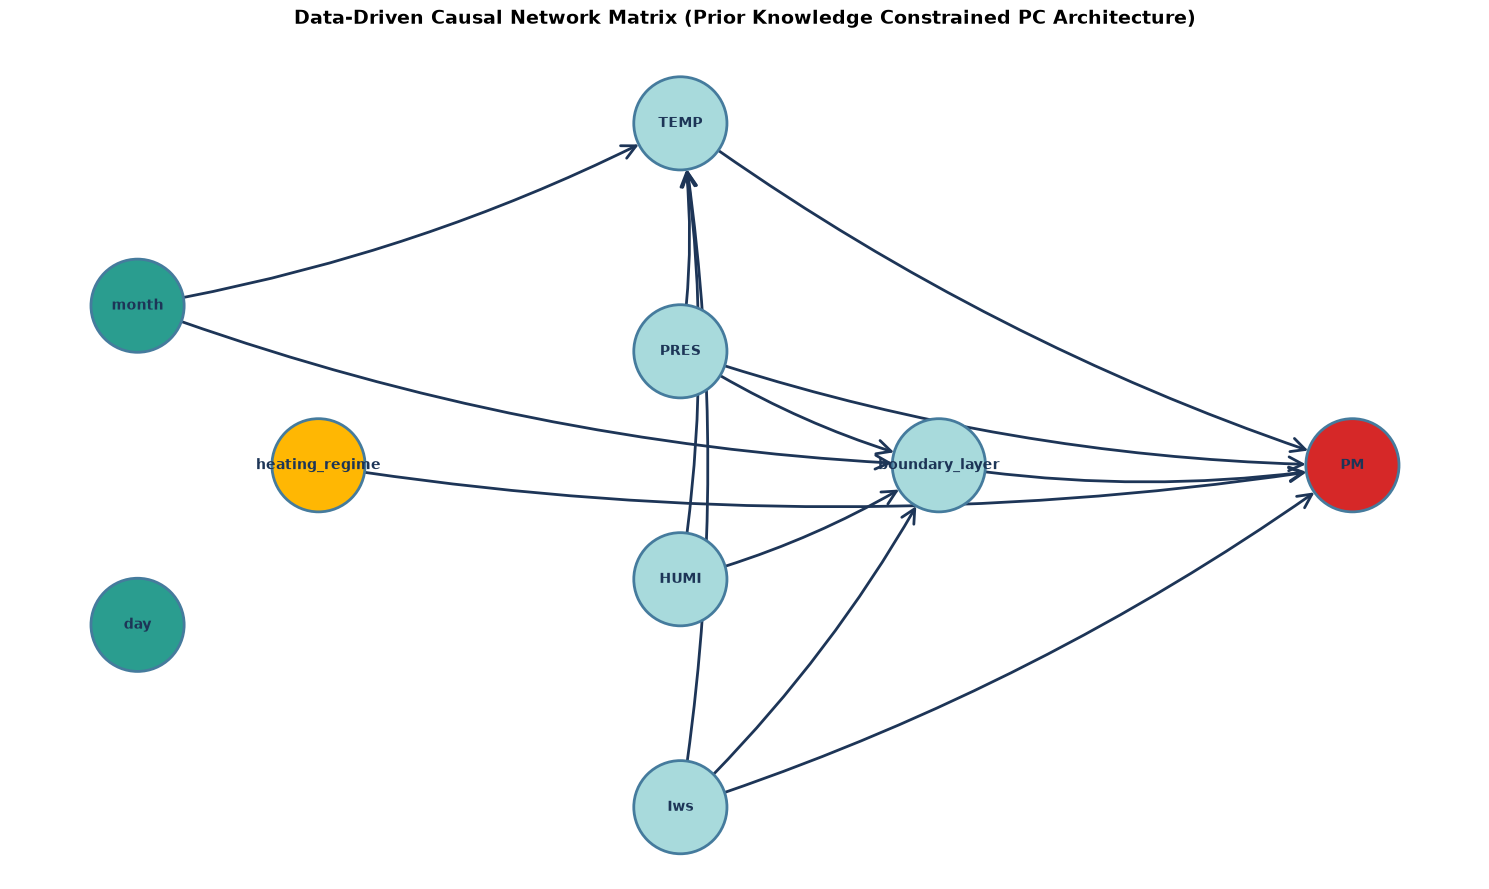

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from castle.algorithms import PC
from castle.common.priori_knowledge import PrioriKnowledge
from sklearn.preprocessing import StandardScaler

# We aggregate the dataset from hourly to average daily values to reduce noise.
daily_df = (
    df_clean.groupby(["city", "year", "month", "day"])
    .agg(
        TEMP=("TEMP", "mean"),
        PRES=("PRES", "mean"),
        HUMI=("HUMI", "mean"),
        Iws=("Iws", "mean"),
        boundary_layer=("boundary_layer_height (m)", "mean"),
        heating_regime=("heating_regime", "max"),
        PM=("PM", "mean"),
    )
    .reset_index()
)

# We define the features to be included in our DAG.
graph_features = [
    "month",
    "day",
    "heating_regime",
    "TEMP",
    "PRES",
    "HUMI",
    "Iws",
    "boundary_layer",
    "PM",
]
df_graph = daily_df[graph_features].dropna()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_graph)

# gcastle supports including prior knowledge by whitelisting and blacklist. Whitelisting ("required_edge") is a mandatory edge within the graph.
# Generally speaking, whitelisting should not be used because it can introduce bias. In our case it is only used to add the edges from "month" and "day" to "heating_regime".
# This is necessary because switching "heating regime" is not present as a variable in our dataset. We didn't include "heating regime" because it deterministically
# depends on "city" and "date" therefore introducing multicollinearity.
priori = PrioriKnowledge(n_nodes=len(graph_features))
idx = {name: i for i, name in enumerate(graph_features)}

# Rule A: Time (month, day) is exogenous therefore can only act as source.
for var in graph_features:
    if var not in ["month", "day"]:
        priori.add_forbidden_edge(idx[var], idx["month"])
        priori.add_forbidden_edge(idx[var], idx["day"])

# Rule B: Weather can not cause heating_regime
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer", "PM"]:
    priori.add_forbidden_edge(idx[weather_var], idx["heating_regime"])

# Regel C: Administrative Verknüpfung der Heizpolitik
#priori.add_required_edge(idx["month"], idx["heating_regime"])
#priori.add_required_edge(idx["day"], idx["heating_regime"])

# Regel D: Die Heizpolitik kann nicht die physikalische Baseline verändern
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer"]:
    priori.add_forbidden_edge(idx["heating_regime"], idx[weather_var])

# Regel E: Thermodynamische und kausale Sperren aus dem vorherigen Schritt
priori.add_forbidden_edge(idx["PM"], idx["TEMP"])
priori.add_forbidden_edge(idx["TEMP"], idx["PRES"])

# ── FIX NEU: DIE FINALEN METEOROLOGISCHEN SPERREN ENFORCEN ──
# 1. Der Kalendertag (day) darf KEINE Wettervariablen direkt physikalisch verursachen!
# (Er darf ausschließlich die administrative heating_regime triggern)
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer", "PM"]:
    priori.add_forbidden_edge(idx["day"], idx[weather_var])

# 2. Feinstaub (PM) darf KEINE einzige meteorologische Variable rückwärts beeinflussen!
# Das blockiert den PM ──> boundary_layer Fehler sowie alle potenziellen anderen Reverse-Causality-Pfade
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer"]:
    priori.add_forbidden_edge(idx["PM"], idx[weather_var])

print("── NATIVE PRIORI KNOWLEDGE TENSOR VOLLSTÄNDIG OPTIMIERT ──")

# 4. PC-Modell mit den finalen Restriktionen fitten
pc_model = PC(priori_knowledge=priori)
pc_model.learn(scaled_data)
adj_mat = pc_model.causal_matrix

# 5. NetworkX Graph aufbauen
G = nx.DiGraph()
G.add_nodes_from(graph_features)

for i, source in enumerate(graph_features):
    for j, target in enumerate(graph_features):
        if adj_mat[i, j] == 1:
            G.add_edge(source, target)

# Hardcoded Left-to-Right Layout
pos = {
    "month": (-2.5, 0.7),
    "day": (-2.5, -0.7),
    "heating_regime": (-1.8, 0.0),
    "TEMP": (-0.4, 1.5),
    "PRES": (-0.4, 0.5),
    "HUMI": (-0.4, -0.5),
    "Iws": (-0.4, -1.5),
    "boundary_layer": (0.6, 0.0),
    "PM": (2.2, 0.0),
}

# 6. Plot zeichnen
plt.figure(figsize=(15, 9))

node_colors = [
    (
        "#2a9d8f"
        if n in ["month", "day"]
        else (
            "#ffb703"
            if n == "heating_regime"
            else "#d62828" if n == "PM" else "#a8dadc"
        )
    )
    for n in graph_features
]

nx.draw_networkx_nodes(
    G, pos, node_size=4500, node_color=node_colors, edgecolors="#457b9d", linewidths=2
)

nx.draw_networkx_edges(
    G, pos, node_size=4500, arrows=True, arrowstyle="->", arrowsize=25,
    edge_color="#1d3557", width=2, connectionstyle="arc3,rad=0.08"
)

nx.draw_networkx_labels(
    G, pos, font_size=10, font_weight="bold", font_color="#1d3557", verticalalignment="center"
)

plt.title("Data-Driven Causal Network Matrix (Prior Knowledge Constrained PC Architecture)", fontsize=14, fontweight='bold', pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
import os

# Fügt den Graphviz-Ordner temporär für dieses Skript hinzu
os.environ["PATH"] += os.path.pathsep + r"C:\Program Files\Graphviz\bin"

✓ Daten-Shape: (7419, 9)
✓ Skalierte Variablen: ['TEMP', 'PRES', 'HUMI', 'Iws', 'boundary_layer', 'PM']
✓ Unskalierte Variablen: ['month', 'day', 'heating_regime']
── BACKGROUND KNOWLEDGE GENERIERT ───────────────────────────────────
  • 9 Knoten
  • Zeit-Variablen exogen: month, day
  • heating_regime geschützt vor Wetter-Kausalität

[causal-learn] > FCI wird ausgeführt (latente Confounder + Background Knowledge)...


  0%|          | 0/9 [00:00<?, ?it/s]

Starting BK Orientation.
Finishing BK Orientation.
Starting BK Orientation.
Finishing BK Orientation.
X3 --> X6
X5 --> X4
X9 --> X8
✓ FCI abgeschlossen

[Post-Processing] > Verbotene Kanten werden entfernt...
✓ Insgesamt entfernte verbotene Kanten: 0

✓ Graph gespeichert unter: fci_causal_graph_final.png


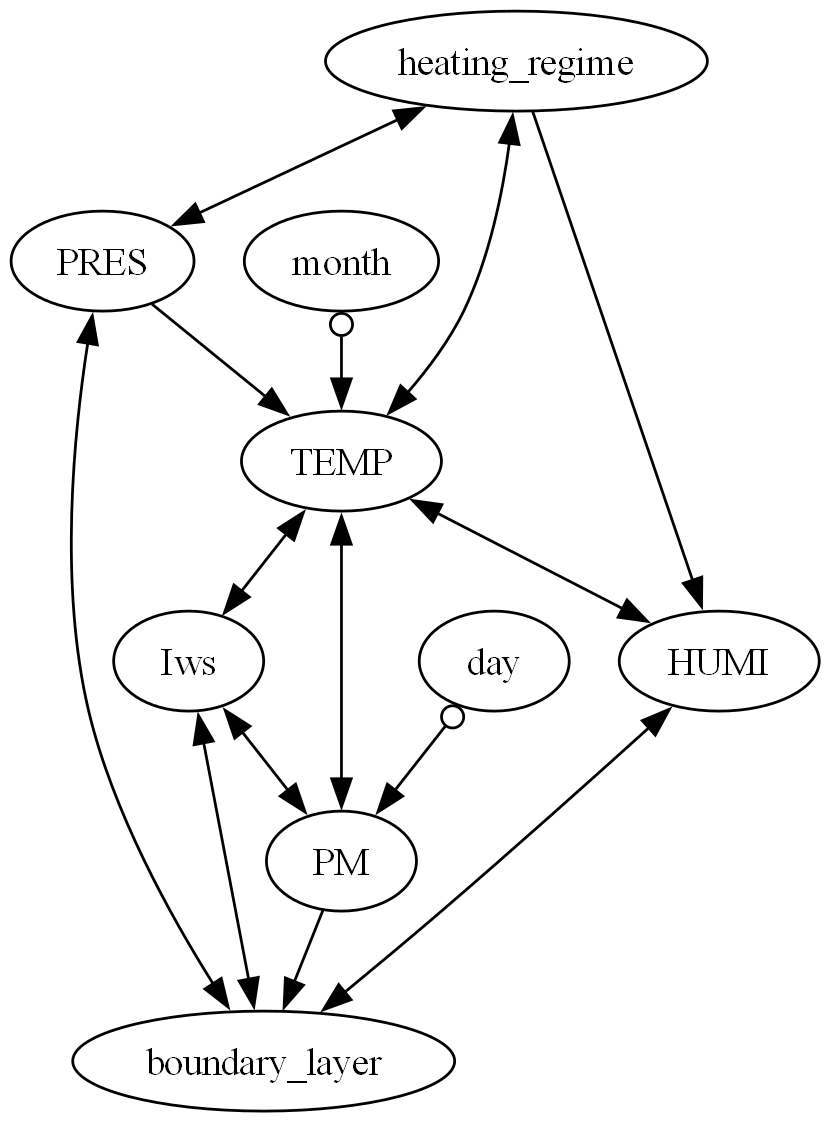


── FINALE KAUSALE KANTEN ────────────────────────────────────────────


AttributeError: Tail

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.utils.GraphUtils import GraphUtils
from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler

# =============================================================================
# 1. DATA PREPARATION: Downsample to daily intervals
# =============================================================================
daily_df = (
    df_clean.groupby(["city", "year", "month", "day"])
    .agg(
        TEMP=("TEMP", "mean"),
        PRES=("PRES", "mean"),
        HUMI=("HUMI", "mean"),
        Iws=("Iws", "mean"),
        boundary_layer=("boundary_layer_height (m)", "mean"),
        heating_regime=("heating_regime", "max"),  # 1 if active that day
        PM=("PM", "mean"),
    )
    .reset_index()
)

# =============================================================================
# 2. SELECT VARIABLES & FIX SCALING (KRITISCH!)
# =============================================================================
graph_features = [
    "month", "day", "heating_regime", "TEMP", "PRES", "HUMI", "Iws", 
    "boundary_layer", "PM"
]
df_graph = daily_df[graph_features].dropna()

# FIX: Nur kontinuierliche physikalische Variablen skalieren, NICHT kategoriale/Zeit-Variablen
continuous_vars = ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer", "PM"]
categorical_vars = ["month", "day", "heating_regime"]

df_scaled = df_graph.copy()
scaler = StandardScaler()
df_scaled[continuous_vars] = scaler.fit_transform(df_graph[continuous_vars])
# Kategoriale Variablen bleiben unskaliert (behält ihre diskrete Natur bei)

scaled_data = df_scaled.values

print(f"✓ Daten-Shape: {scaled_data.shape}")
print(f"✓ Skalierte Variablen: {continuous_vars}")
print(f"✓ Unskalierte Variablen: {categorical_vars}")

# =============================================================================
# 3. BACKGROUND KNOWLEDGE AUFBAUEN
# =============================================================================
bk = BackgroundKnowledge()
nodes = {name: GraphNode(name) for name in graph_features}

# Rule A: Zeit (month, day) ist vollständig exogen
for var in graph_features:
    if var not in ["month", "day"]:
        bk.add_forbidden_by_node(nodes[var], nodes["month"])
        bk.add_forbidden_by_node(nodes[var], nodes["day"])

# Rule B: Wetterparameter KÖNNEN NICHT die Policy verursachen
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer", "PM"]:
    bk.add_forbidden_by_node(nodes[weather_var], nodes["heating_regime"])

# Rule C: Politische Entscheidungen können absolute Physik nicht ändern
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer"]:
    bk.add_forbidden_by_node(nodes["heating_regime"], nodes[weather_var])

print("── BACKGROUND KNOWLEDGE GENERIERT ───────────────────────────────────")
print(f"  • {len(graph_features)} Knoten")
print(f"  • Zeit-Variablen exogen: month, day")
print(f"  • heating_regime geschützt vor Wetter-Kausalität")

# =============================================================================
# 4. FCI ALGORITHMUS AUSFÜHREN
# =============================================================================
print("\n[causal-learn] > FCI wird ausgeführt (latente Confounder + Background Knowledge)...")

g, edges = fci(
    scaled_data,
    independence_test_method="fisherz",
    alpha=0.01,           # Strenger als 0.05 für weniger falsch-positive Kanten
    background_knowledge=bk,
    depth=-1,             # Maximale Konditionierungs-Tiefe
    verbose=False
)

print("✓ FCI abgeschlossen")

# =============================================================================
# 5. POST-PROCESSING: Verbotene Kanten erzwingen (Sicherheitsnetz)
# =============================================================================
print("\n[Post-Processing] > Verbotene Kanten werden entfernt...")

from causallearn.graph.Endpoint import Endpoint

forbidden_pairs = [
    ("heating_regime", "TEMP"),
    ("heating_regime", "PRES"),
    ("heating_regime", "HUMI"),
    ("heating_regime", "Iws"),
    ("heating_regime", "boundary_layer"),
    ("TEMP", "heating_regime"),
    ("PRES", "heating_regime"),
    ("HUMI", "heating_regime"),
    ("Iws", "heating_regime"),
    ("boundary_layer", "heating_regime"),
    ("PM", "heating_regime"),
]

removed_count = 0
for edge in list(g.get_graph_edges()):
    node1 = edge.get_node1().get_name()
    node2 = edge.get_node2().get_name()
    
    if (node1, node2) in forbidden_pairs or (node2, node1) in forbidden_pairs:
        g.remove_edge(edge)
        print(f"  ❌ Entfernt: {node1} -- {node2}")
        removed_count += 1

print(f"✓ Insgesamt entfernte verbotene Kanten: {removed_count}")

# =============================================================================
# 6. VISUALISIERUNG
# =============================================================================
pyd = GraphUtils.to_pydot(g, labels=graph_features)

output_filename = "fci_causal_graph_final.png"
pyd.write_png(output_filename)

print(f"\n✓ Graph gespeichert unter: {output_filename}")
display(Image(output_filename))

# =============================================================================
# 7. KANTEN-LISTE EXPORTIEREN (für Dokumentation/Reproduzierbarkeit)
# =============================================================================
from causallearn.graph.Endpoint import Endpoint

print("\n── FINALE KAUSALE KANTEN ────────────────────────────────────────────")
edge_list = []

for edge in g.get_graph_edges():
    node1 = edge.get_node1().get_name()
    node2 = edge.get_node2().get_name()
    
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    
    # HINWEIS: Endpoint-Konstanten sind GROSSGESCHRIEBEN in causal-learn
    if ep1 == Endpoint.TAIL and ep2 == Endpoint.ARROW:
        edge_type = "→"
    elif ep1 == Endpoint.ARROW and ep2 == Endpoint.TAIL:
        edge_type = "←"
    elif ep1 == Endpoint.ARROW and ep2 == Endpoint.ARROW:
        edge_type = "↔"
    elif ep1 == Endpoint.CIRCLE and ep2 == Endpoint.ARROW:
        edge_type = "o→"
    elif ep1 == Endpoint.ARROW and ep2 == Endpoint.CIRCLE:
        edge_type = "←o"
    elif ep1 == Endpoint.CIRCLE and ep2 == Endpoint.CIRCLE:
        edge_type = "o-o"
    elif ep1 == Endpoint.TAIL and ep2 == Endpoint.TAIL:
        edge_type = "--"
    else:
        edge_type = f"{ep1}-{ep2}"
    
    edge_list.append((node1, node2, edge_type))
    print(f"  {node1} {edge_type} {node2}")

edge_df = pd.DataFrame(edge_list, columns=["from", "to", "edge_type"])
edge_df.to_csv("fci_causal_edges.csv", index=False)
print(f"\n✓ Kanten-Liste exportiert nach: fci_causal_edges.csv")

In [ ]:
import geopandas as gpd
# Lade die Stadtgrenzen
cities = gpd.read_file("city_boundaries/all_cities_boundaries.geojson")

# Puffer hinzufügen (1°)
cities["geometry"] = cities.geometry.buffer(1.0)

C:\Users\olive\AppData\Local\Temp\ipykernel_13600\3177110950.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cities["geometry"] = cities.geometry.buffer(1.0)


In [ ]:
import numpy as np

def calculate_dynamic_buffer(wind_speed, wind_direction, season="winter"):
    """
    Berechnet die Puffergröße basierend auf Wind und Jahreszeit.

    Args:
        wind_speed (float): Windgeschwindigkeit in km/h.
        wind_direction (float): Windrichtung in ° (0–360).
        season (str): "winter" oder "summer" (beeinflusst Stabilitätsfaktor).

    Returns:
        float: Puffergröße in Grad.
    """
    # Stabilitätsfaktor (Winter: 1.5, Sommer: 0.8)
    k = 1.5 if season == "winter" else 0.8

    # Transportzeit (Winter: 48 h, Sommer: 24 h)
    t = 48 if season == "winter" else 24

    # Puffergröße in km
    buffer_km = wind_speed * t * k

    # Umrechnung km → Grad (1° ≈ 111 km)
    buffer_deg = buffer_km / 111

    return min(buffer_deg, 3.0)  # Maximal 3° (≈300 km)


from shapely.geometry import Polygon

def create_wind_direction_buffer(city_geometry, buffer_deg, wind_direction):
    """
    Erstellt einen Puffer als Kreisausschnitt in Windrichtung.

    Args:
        city_geometry (shapely.geometry): Stadtgrenze.
        buffer_deg (float): Puffergröße in Grad.
        wind_direction (float): Windrichtung in ° (0–360).

    Returns:
        shapely.geometry.Polygon: Pufferzone.
    """
    city_center = city_geometry.centroid

    # Winkel in Radiant umrechnen (±45° um die Windrichtung)
    angle_start = np.radians(wind_direction - 45)
    angle_end = np.radians(wind_direction + 45)

    # Eckpunkte des Kreisausschnitts
    points = [
        (city_center.x + buffer_deg * 111 * np.sin(angle_start),
         city_center.y + buffer_deg * 111 * np.cos(angle_start)),
        (city_center.x + buffer_deg * 111 * np.sin(angle_end),
         city_center.y + buffer_deg * 111 * np.cos(angle_end)),
        (city_center.x, city_center.y)
    ]

    return Polygon(points)


import xarray as xr
import pandas as pd

def extract_emissions_with_dynamic_buffer(city_name, wind_data, edgar_file, season="winter"):
    """
    Extrahiert EDGAR-Emissionen mit dynamischem Puffer.

    Args:
        city_name (str): Name der Stadt.
        wind_data (pd.DataFrame): Winddaten (time, wind_speed, wind_direction).
        edgar_file (str): Pfad zur EDGAR-Datei.
        season (str): "winter" oder "summer".

    Returns:
        pd.DataFrame: Emissionen mit Winddaten.
    """
    city = cities[cities["name"] == city_name].iloc[0]
    emissions_list = []

    for _, row in wind_data.iterrows():
        # Dynamischen Puffer berechnen
        buffer_deg = calculate_dynamic_buffer(row["wind_speed"], row["wind_direction"], season)
        buffer_polygon = create_wind_direction_buffer(city.geometry, buffer_deg, row["wind_direction"])

        # EDGAR-Daten laden
        ds = xr.open_dataset(edgar_file)

        # Emissionen innerhalb des Puffers extrahieren
        city_emissions = ds.sel(
            lat=slice(buffer_polygon.bounds[1], buffer_polygon.bounds[3]),
            lon=slice(buffer_polygon.bounds[0], buffer_polygon.bounds[2])
        ).emissions.sum(dim=["lat", "lon"]).to_dataframe().reset_index()

        # Winddaten hinzufügen
        city_emissions["wind_speed"] = row["wind_speed"]
        city_emissions["wind_direction"] = row["wind_direction"]
        emissions_list.append(city_emissions)

    return pd.concat(emissions_list)

Data aggregation

In [ ]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import os
from shapely.geometry import Point
#B: load city boundaries
# Path to city boundaries
boundaries_path = "city_boundaries/all_cities_boundaries.geojson"

# Load boundaries
gdf_cities = gpd.read_file(boundaries_path)

# Keep only relevant columns and rename for clarity
gdf_cities = gdf_cities[['NAME_1', 'NAME_2', 'geometry']]
gdf_cities = gdf_cities.rename(columns={'NAME_1': 'province', 'NAME_2': 'city'})

# Filter for your cities of interest
cities_of_interest = ['Beijing', 'Chengdu', 'Guangzhou', 'Shanghai', 'Shenyang']
gdf_cities = gdf_cities[gdf_cities['city'].isin(cities_of_interest)]

# Check
print(gdf_cities.head())
#c: Load EDGAR Emissions Data
# Directory containing EDGAR files
edgar_dir = "edgar_extracted_highres"

# List of pollutants
pollutants = ['bc', 'oc', 'pm2_5', 'so2']

# Initialize an empty DataFrame to store all emissions
df_emissions = pd.DataFrame()

# Loop through each pollutant file
for pollutant in pollutants:
    file_path = os.path.join(edgar_dir, f"edgar_{pollutant}_highres.csv")

    # Load the CSV
    df = pd.read_csv(file_path)

    # Add pollutant column
    df['pollutant'] = pollutant

    # Append to the main DataFrame
    df_emissions = pd.concat([df_emissions, df], ignore_index=True)

# Check
print(df_emissions.head())

    province       city                                           geometry
0    Beijing    Beijing  MULTIPOLYGON (((116.71038 39.61697, 116.69884 ...
1  Guangdong  Guangzhou  MULTIPOLYGON (((113.5668 22.74236, 113.5668 22...
2   Liaoning   Shenyang  MULTIPOLYGON (((123.71957 41.51173, 123.71618 ...
3   Shanghai   Shanghai  MULTIPOLYGON (((122.27847 30.63264, 122.2782 3...
4    Sichuan    Chengdu  MULTIPOLYGON (((103.46811 30.1304, 103.46385 3...
      city  year pollutant          sector    lat     lon  emissions
0  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.45   0.000000
1  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.55   0.000000
2  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.65   0.000000
3  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.75   1.512519
4  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.85   0.000000


In [ ]:
# Convert EDGAR data to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_emissions['lon'], df_emissions['lat'])]
gdf_emissions = gpd.GeoDataFrame(df_emissions, geometry=geometry, crs="EPSG:4326")

# Check
print(gdf_emissions.head())

# Check CRS of both GeoDataFrames
print("City boundaries CRS:", gdf_cities.crs)
print("Emissions CRS:", gdf_emissions.crs)

# If they don't match, reproject emissions to match city boundaries
if gdf_emissions.crs != gdf_cities.crs:
    gdf_emissions = gdf_emissions.to_crs(gdf_cities.crs)

# Spatial join: emissions points within city boundaries
gdf_joined = gpd.sjoin(gdf_emissions, gdf_cities, how="inner", predicate="within")

# Check
print(gdf_joined.head())
#3B
# Spatial Join: Emissionspunkte innerhalb der Stadtgrenzen
# WICHTIG: Verwende 'how="inner"' und behalte die Spalten explizit bei
gdf_joined = gpd.sjoin(
    gdf_emissions,  # Left DataFrame (Emissionspunkte)
    gdf_cities,     # Right DataFrame (Stadtgrenzen)
    how="inner",    # Behalte nur Punkte, die in einer Stadt liegen
    predicate="within"
)

# Überprüfe die Spalten nach dem Join
print("Spalten nach dem Join:", gdf_joined.columns)

# Falls 'city' fehlt, extrahiere es aus dem rechten DataFrame
if 'city' not in gdf_joined.columns:
    # Annahme: Die Stadtinformation ist in 'NAME_2' (GADM) oder 'city' (falls umbenannt)
    if 'NAME_2' in gdf_joined.columns:
        gdf_joined['city'] = gdf_joined['NAME_2']
    elif 'city_right' in gdf_joined.columns:  # Geopandas fügt manchmal '_right' an
        gdf_joined['city'] = gdf_joined['city_right']
    else:
        # Falls nicht, nutze den Index der Stadtgrenzen (manuell)
        # Erstelle eine Zuordnung von Index zu Stadtname
        city_mapping = gdf_cities['city'].to_dict()
        gdf_joined['city'] = gdf_joined.index.map(city_mapping)

# Überprüfe erneut
print(gdf_joined[['city', 'year', 'pollutant', 'sector', 'emissions']].head())
#3C
# Gruppiere nach Stadt, Jahr, Schadstoff und Sektor, dann summiere Emissionen
df_aggregated = gdf_joined.groupby([
    'city',        # Stadtname (z. B. 'Beijing')
    'year',        # Jahr
    'pollutant',   # Schadstoff (z. B. 'pm2_5')
    'sector'       # Sektor (z. B. 'BUILDINGS')
])['emissions'].sum().reset_index()

# Überprüfe das Ergebnis
print(df_aggregated.head())
#4
# Save to CSV
output_path = "edgar_aggregated_emissions.csv"
df_aggregated.to_csv(output_path, index=False)
print(f"Aggregated emissions saved to {output_path}")

      city  year pollutant          sector    lat     lon  emissions  \
0  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.45   0.000000   
1  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.55   0.000000   
2  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.65   0.000000   
3  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.75   1.512519   
4  Beijing  2010        bc  POWER_INDUSTRY  36.35  111.85   0.000000   

               geometry  
0  POINT (111.45 36.35)  
1  POINT (111.55 36.35)  
2  POINT (111.65 36.35)  
3  POINT (111.75 36.35)  
4  POINT (111.85 36.35)  
City boundaries CRS: EPSG:4326
Emissions CRS: EPSG:4326
     city_left  year pollutant          sector    lat     lon  emissions  \
3180   Beijing  2010        bc  POWER_INDUSTRY  39.45  116.35        0.0   
3275   Beijing  2010        bc  POWER_INDUSTRY  39.55  115.75        0.0   
3280   Beijing  2010        bc  POWER_INDUSTRY  39.55  116.25        0.0   
3281   Beijing  2010        bc  POWER_INDUSTRY  39.

In [ ]:
#FÜR MONATLICHE WERTE - WIRD BALD NICHT MEHR BENÖTIGT

import pandas as pd

# Lade deinen bestehenden Datensatz
df_existing = pd.read_csv("dataset_clean.csv")


# Überprüfe die Spalten
print(df_existing.head())
print(df_existing.columns)

# Lade die aggregierten EDGAR-Daten (aus Schritt 4)
df_aggregated = pd.read_csv("edgar_aggregated_emissions.csv")

# Füge eine 'month'-Spalte hinzu (EDGAR ist monatlich, aber dein Datensatz hat 'month')
df_aggregated['month'] = 1  # Platzhalter, wird später mit merge gefüllt

# Passe die Spalten an, um mit deinem Datensatz kompatibel zu sein
df_aggregated = df_aggregated.rename(columns={
    'city': 'city',
    'year': 'year',
    'sector': 'sector',
    'bc': 'bc_emissions',
    'oc': 'oc_emissions',
    'pm2_5': 'pm2_5_emissions',
    'so2': 'so2_emissions'
})

# Überprüfe
print(df_aggregated.head())


# Pivotiere df_aggregated und setze den Index zurück
df_pivoted = df_aggregated.pivot_table(
    index=['city', 'year', 'month'],  # Gruppierung nach Stadt, Jahr, Monat
    columns=['pollutant', 'sector'],  # Spalten für Schadstoff und Sektor
    values='emissions',               # Werte = Emissionen
    fill_value=0                      # Fehlende Werte mit 0 füllen
).reset_index()  # WICHTIG: Setze den Index zurück, um 'city', 'year', 'month' als Spalten zu behalten

# Entferne Unterstriche aus den Spaltennamen
df_pivoted = df_pivoted.rename(columns={
    '_city': 'city',
    '_year': 'year',
    '_month': 'month'
})

# Überprüfe die Spalten
print("Spalten nach Umbenennung:")
print(df_pivoted.columns.tolist())

# Flache die Multi-Index-Spalten zu einfachen Strings
df_pivoted.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] else col[0]
    for col in df_pivoted.columns
]

# Überprüfe die neuen Spaltennamen
print("Spalten nach Flattening:")
print(df_pivoted.columns.tolist())

# Überprüfe erneut
print("Spalten nach Entfernen der Unterstriche:")
print(df_pivoted.columns.tolist())

# Merge mit df_existing
df_merged = pd.merge(
    df_existing,
    df_pivoted,
    on=['city', 'year', 'month'],
    how='left'
)

# Überprüfe, ob die Emissionsspalten jetzt vorhanden sind
print("Spalten in df_merged:")
print(df_merged.columns.tolist())

# Fülle fehlende Werte mit 0
emission_cols = [col for col in df_merged.columns if col not in df_existing.columns]
df_merged[emission_cols] = df_merged[emission_cols].fillna(0)

# Überprüfe
print(df_merged.columns)

      city  year  month  day  hour  season     PM  heating_regime  wind_angle  \
0  Beijing  2010      1    1    23     4.0  129.0               1         NaN   
1  Beijing  2010      1    2     0     4.0  148.0               1       135.0   
2  Beijing  2010      1    2     1     4.0  159.0               1       135.0   
3  Beijing  2010      1    2     2     4.0  181.0               1       135.0   
4  Beijing  2010      1    2     3     4.0  138.0               1       135.0   

   TEMP  ...  HUMI  Iws  wind_direction_10m (°)  boundary_layer_height (m)  \
0  -4.1  ...  42.0  5.0                   339.0                       30.0   
1  -4.4  ...  45.0  4.9                   343.0                       30.0   
2  -4.5  ...  48.0  5.0                   360.0                       30.0   
3  -4.6  ...  55.0  4.5                    29.0                       45.0   
4  -4.9  ...  66.0  4.3                    90.0                       95.0   

     PRES  wind_gusts_10m (km/h)  cloud_cove

── PRIORI KNOWLEDGE MIT EXKLUSIVER STEUERUNG VON HEATING_REGIME DURCH MONTH ──


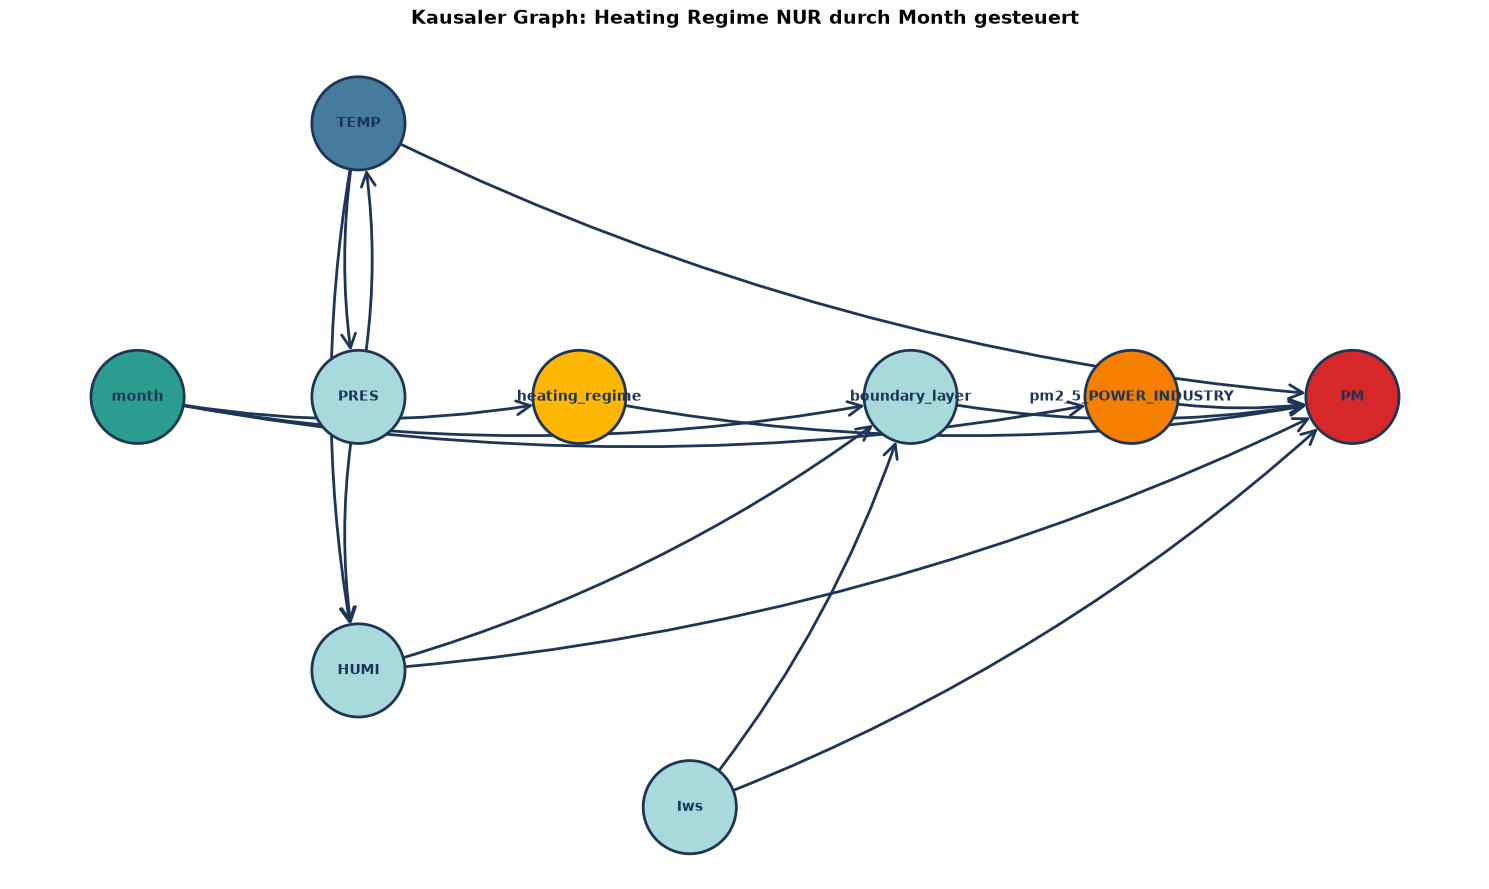

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from castle.algorithms import PC
from castle.common.priori_knowledge import PrioriKnowledge
from sklearn.preprocessing import StandardScaler

# 1. Datensatz auf Monatsebene aggregieren
monthly_df = (
    df_merged.groupby(["city", "year", "month"])
    .agg(
        TEMP=("TEMP", "mean"),
        PRES=("PRES", "mean"),
        HUMI=("HUMI", "mean"),
        Iws=("Iws", "mean"),
        boundary_layer=("boundary_layer_height (m)", "mean"),
        heating_regime=("heating_regime", "max"),
        PM=("PM", "mean"),
        pm2_5_POWER_INDUSTRY=("pm2_5_POWER_INDUSTRY", "first"),
    )
    .reset_index()
)

# 2. Features definieren
graph_features = [
    "month",  # Steuert heating_regime
    "TEMP",   # Wird von month beeinflusst, aber nicht von heating_regime
    "heating_regime",  # Wird NUR von month gesteuert
    "PRES",
    "HUMI",
    "Iws",
    "boundary_layer",
    "pm2_5_POWER_INDUSTRY",
    "PM",
]
df_graph = monthly_df[graph_features].dropna()

# 3. Daten standardisieren
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_graph)

# 4. Priori Knowledge (korrigierte kausale Annahmen)
priori = PrioriKnowledge(n_nodes=len(graph_features))
idx = {name: i for i, name in enumerate(graph_features)}

# Regel A: Zeit (month) ist exogen
for var in graph_features:
    if var != "month":
        priori.add_forbidden_edge(idx[var], idx["month"])

# Regel B: heating_regime wird NUR von month gesteuert
priori.add_required_edge(idx["month"], idx["heating_regime"])  # month → heating_regime
for var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer", "pm2_5_POWER_INDUSTRY", "PM"]:
    priori.add_forbidden_edge(idx[var], idx["heating_regime"])  # Keine anderen Ursachen für heating_regime

# Regel C: heating_regime beeinflusst keine meteorologischen Variablen
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer"]:
    priori.add_forbidden_edge(idx["heating_regime"], idx[weather_var])

# Regel D: Emissionen beeinflussen Temperatur nicht
priori.add_forbidden_edge(idx["pm2_5_POWER_INDUSTRY"], idx["TEMP"])

# Regel E: PM beeinflusst keine meteorologischen Variablen oder Emissionen
for weather_var in ["TEMP", "PRES", "HUMI", "Iws", "boundary_layer", "pm2_5_POWER_INDUSTRY"]:
    priori.add_forbidden_edge(idx["PM"], idx[weather_var])

print("── PRIORI KNOWLEDGE MIT EXKLUSIVER STEUERUNG VON HEATING_REGIME DURCH MONTH ──")

# 5. PC-Algorithmus mit höherem Signifikanzniveau (sparsamerer Graph)
pc_model = PC(priori_knowledge=priori, alpha=0.05)
pc_model.learn(scaled_data)
adj_mat = pc_model.causal_matrix

# 6. NetworkX Graph aufbauen
G = nx.DiGraph()
G.add_nodes_from(graph_features)

for i, source in enumerate(graph_features):
    for j, target in enumerate(graph_features):
        if adj_mat[i, j] == 1:
            G.add_edge(source, target)

# 7. Layout anpassen (manuell für bessere Lesbarkeit)
pos = {
    "month": (-2.5, 0.0),
    "TEMP": (-1.5, 1.0),
    "heating_regime": (-0.5, 0.0),
    "PRES": (-1.5, 0.0),
    "HUMI": (-1.5, -1.0),
    "Iws": (0.0, -1.5),
    "boundary_layer": (1.0, 0.0),
    "pm2_5_POWER_INDUSTRY": (2.0, 0.0),
    "PM": (3.0, 0.0),
}

# 8. Plot zeichnen
plt.figure(figsize=(15, 9))

node_colors = [
    "#2a9d8f" if n == "month" else
    "#457b9d" if n == "TEMP" else
    "#ffb703" if n == "heating_regime" else
    "#f77f00" if n == "pm2_5_POWER_INDUSTRY" else
    "#d62828" if n == "PM" else
    "#a8dadc" for n in graph_features
]

nx.draw_networkx_nodes(
    G, pos, node_size=4500, node_color=node_colors, edgecolors="#1d3557", linewidths=2
)

nx.draw_networkx_edges(
    G, pos, node_size=4500, arrows=True, arrowstyle="->", arrowsize=25,
    edge_color="#1d3557", width=2, connectionstyle="arc3,rad=0.1"
)

nx.draw_networkx_labels(
    G, pos, font_size=10, font_weight="bold", font_color="#1d3557", verticalalignment="center"
)

plt.title("Kausaler Graph: Heating Regime NUR durch Month gesteuert", fontsize=14, fontweight='bold', pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()

Spalten nach Pivot:
['city', 'sector', 'bc', 'oc', 'pm2_5', 'so2']


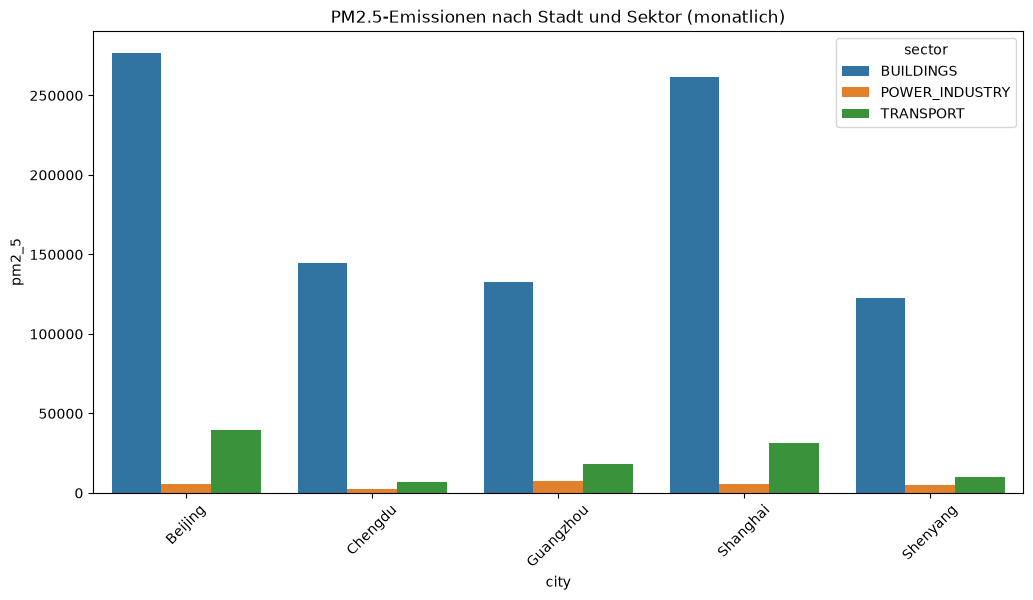

Spalten in beijing_pm25:
['city', 'year', 'pollutant', 'sector', 'emissions', 'month']


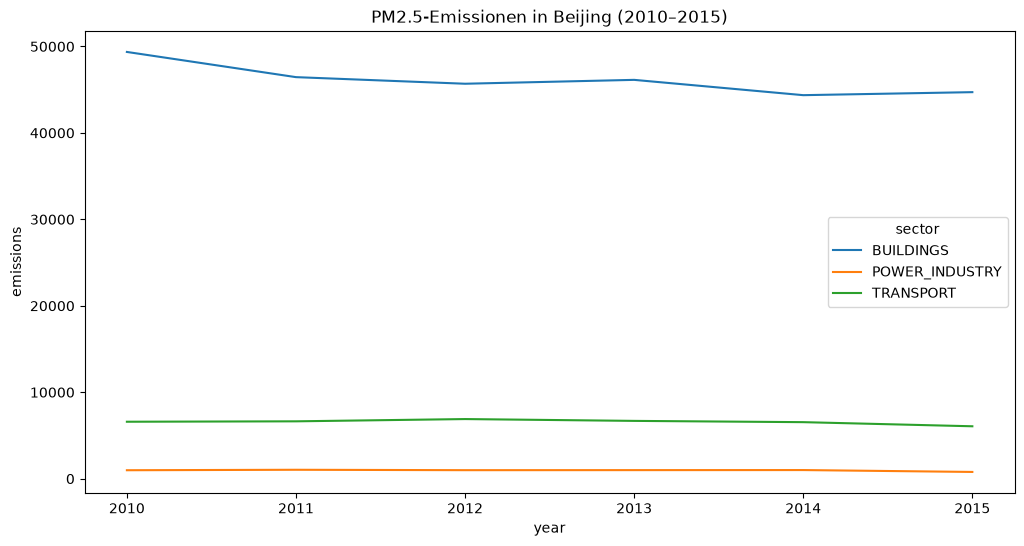

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Beispiel: PM2.5-Emissionen nach Stadt und Sektor
plt.figure(figsize=(12, 6))

# Pivotiere df_aggregated, um separate Spalten für jeden Sektor und Schadstoff zu erhalten
df_plot = df_aggregated.pivot_table(
    index=['city', 'sector'],  # Gruppierung nach Stadt und Sektor
    columns='pollutant',       # Spalten für Schadstoffe
    values='emissions',        # Werte = Emissionen
    aggfunc='sum'              # Summiere Emissionen pro Sektor/Schadstoff
).reset_index()

# Flache die Multi-Index-Spalten (z. B. ('pm2_5', '') → 'pm2_5')
df_plot.columns = [
    col if isinstance(col, str) else col[0]
    for col in df_plot.columns
]

# Überprüfe die Spalten
print("Spalten nach Pivot:")
print(df_plot.columns.tolist())

sns.barplot(
    data=df_plot,
    x='city',
    y='pm2_5',  # Jetzt ist 'pm2_5' eine Spalte
    hue='sector'
)
plt.title("PM2.5-Emissionen nach Stadt und Sektor (monatlich)")
plt.xticks(rotation=45)
plt.show()

# Beispiel: PM2.5-Emissionen in Beijing über die Zeit
# Filtere nur PM2.5-Emissionen für Beijing
beijing_pm25 = df_aggregated[
    (df_aggregated['city'] == 'Beijing') &
    (df_aggregated['pollutant'] == 'pm2_5')
]

# Überprüfe die Spalten
print("Spalten in beijing_pm25:")
print(beijing_pm25.columns.tolist())

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=beijing_pm25,
    x='year',
    y='emissions',  # Verwende 'emissions' statt 'pm2_5_emissions'
    hue='sector'
)
plt.title("PM2.5-Emissionen in Beijing (2010–2015)")
plt.show()